In [137]:
import pickle # Load refs and annotations
import json
import os
import pandas as pd
import numpy as np
import pprint
import json
import cv2
import random

from typing import Any, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.utils.tensorboard import SummaryWriter

import torchvision
import torchvision.transforms as transforms
from torchvision.utils import draw_bounding_boxes
from torchvision import models
import torchmetrics

import pytorch_lightning as pl
from pytorch_lightning.utilities.types import STEP_OUTPUT

from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers import CLIPProcessor, CLIPModel

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import clip
from ultralytics import YOLO
from PIL import Image, ImageDraw

from ipywidgets import FloatProgress
import math 
from torch.nn.modules.batchnorm import _BatchNorm
from torchvision.ops import box_convert

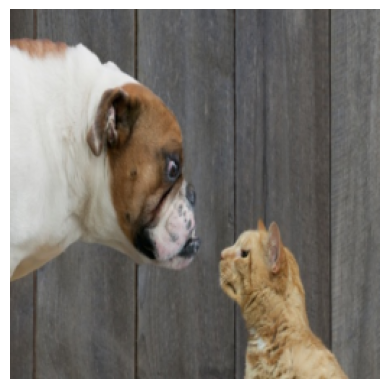

In [138]:
from torchvision.transforms import v2
from PIL import Image
import matplotlib.pyplot as plt

# Load the image
image = Image.open('woof_meow.jpg')  # Replace 'your_image.jpg' with the path to your image file

# Define a transformation
transform = v2.Compose([
    v2.Resize((256, 256)),  # Resize the image to 256x256 pixels
    v2.ToTensor(),          # Convert the image to a PyTorch tensor
])

# Apply the transformation to the image
transformed_image = transform(image)

transformed_image = transformed_image.permute(1, 2, 0)  # Change shape to (H, W, C)
transformed_image = transformed_image.numpy()  # Convert to a numpy array
transformed_image = (transformed_image * 255).astype('uint8')  # Convert to [0, 255] range

# Display the image
plt.imshow(transformed_image)
plt.axis('off')  # Hide the axis
plt.show()

In [139]:
with open("../refcocog/annotations/refs(umd).p", "rb") as fp:
  refs = pickle.load(fp)

# 'annotations' will be a dict object mapping the 'annotation_id' to the 'bbox' to make search faster
with open("../refcocog/annotations/instances.json", "rb") as fp:
  data = json.load(fp)
  annotations = dict(sorted({ann["id"]: ann["bbox"] for ann in data["annotations"]}.items()))

In [140]:
def getcaption(elem):
    li = []
    for e in elem["sentences"]:
        li.append(e['raw'])
    return li

In [141]:
class DataAugmentation():
    # This class is used to perform tranformation in order to have augmented data

    def blur(self,img,bbox):
        # Gaussian Blur the image
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.GaussianBlur(kernel_size=5),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def rotate(self,img,bbox):
        # Rotate the image
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.RandomRotation(degrees=20),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox
    def grayscale(self,img,bbox):
        # Convert the image to grayscale
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Grayscale(num_output_channels=3),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox
    def colorrand(self,img,bbox):
        # Randomly change the color of the image
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.ColorJitter(brightness=0.01*random.randrange(1,50), contrast=0.01*random.randrange(1,50), saturation=0.01*random.randrange(1,50), hue=0.01*random.randrange(1,50)),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox
    def Hflip(self,img,bbox):
       # flip horizontally both image and bbox
      #img = v2.functional.hflip(img)
      cxcywh_format = box_convert(bbox, 'xyxy', 'cxcywh')

      # flip the y coordinate
      transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.RandomHorizontalFlip(p=1),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
      img = transform(img)
      cxcywh_format[0] = img.shape[2] - cxcywh_format[0]

      bbox = box_convert(cxcywh_format, 'cxcywh', 'xyxy')
      return img, bbox

    def random_augmentation(self,img,bbox):
      # Randomly choose a transformation to be applied to the image
      n = random.randint(0, 4)
      if n == 0:
        return DataAugmentation.blur(self,img,bbox)
      elif n == 1:
        return DataAugmentation.Hflip(self,img,bbox)
      elif n == 2:
        return DataAugmentation.grayscale(self,img,bbox)
      elif n == 3:
        return DataAugmentation.colorrand(self,img,bbox)
      else:
        return DataAugmentation.Hflip(self,img,bbox)
      
      # def random_augmentation(self,img,bbox):
      # # Randomly choose a transformation to be applied to the image
      # n = random.randint(0, 5)
      # if n == 0:
      #   return DataAugmentation.blur(self,img,bbox)
      # elif n == 1:
      #   return DataAugmentation.rotate(self,img,bbox)
      # elif n == 2:
      #   return DataAugmentation.grayscale(self,img,bbox)
      # elif n == 3:
      #   return DataAugmentation.colorrand(self,img,bbox)
      # else:
      #   return DataAugmentation.Hflip(self,img,bbox)


In [149]:
class RefCOCOG(Dataset):
    def __init__(self, refs, model, preprocess, annotations, split="train", device='cpu', count=32):
        self.clip_model, self.clip_preprocess = model, preprocess
        self.device = device
        self.texts = []
        self.filepaths = []
        self.gt = []
        self.cls = []
        self.AUG = DataAugmentation()
        
        # Define your augmentations
        # self.augmentations = transforms.Compose([
        #     ColorJitterBbox(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
        #     RandomRotationBbox(degrees=15),
        #     HorizontalFlipBbox(p=0.5),
        #     ResizeBbox(size=(224, 224))  # Resize all images to 224x224
        # ])
        
        temp = 0
        for elem in [d for d in refs if d["split"] == split]:
            # Retrieve Single image
            file_name = os.path.join("../refcocog/images/", f'{"_".join(elem["file_name"].split("_")[:3])}.jpg')
            image = Image.open(file_name)

            # Retrieve possible ground truth measures
            cls = elem['category_id']
            gt = annotations[elem['ann_id']]
            bbox_tensor = torch.tensor(gt, device=self.device)
            new_bbox = box_convert(bbox_tensor, 'xywh', 'xyxy')

            # Get all texts related to the picture
            sentences = elem['sentences']
            self.texts.append(clip.tokenize(sentences[0]['raw']))
            self.gt.append(new_bbox)
            self.cls.append(cls)
            self.filepaths.append(file_name)
            temp += 1
            if temp > count:
                break

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        gt = self.gt[idx]
        cls = self.cls[idx]
        filename = self.filepaths[idx]
        image = Image.open(filename)
        #self.clip_preprocess(image)
        # Apply augmentations
        image = self.clip_preprocess(image).to(device)
        image, gt = self.AUG.random_augmentation(image,gt)
        #image = self.clip_preprocess
        return text, image, gt, cls, filename

In [150]:
device ='cpu'

In [151]:
clip_model, clip_preprocess = clip.load("RN50", device='cpu')

In [152]:
# create dataset and dataloader
print("----------------------Processing train split----------------------------")
dataset_train = RefCOCOG(refs, clip_model, clip_preprocess, annotations, device=device, split="train")
dataloader_train = DataLoader(dataset_train, batch_size=16)
len_train = len(dataset_train)
print(f"Numero esempi in train = {len_train}")

print("----------------------Processing test split-----------------------------")
dataset_test = RefCOCOG(refs, clip_model, clip_preprocess, annotations, device=device, split="test")
dataloader_test = DataLoader(dataset_test, batch_size=16)
len_test = len(dataset_test)
print(f"Numero esempi in train = {len_test}")

print("----------------------Processing eval split-----------------------------")
dataset_eval = RefCOCOG(refs, clip_model, clip_preprocess, annotations, device=device, split="val")
dataloader_eval = DataLoader(dataset_eval, batch_size=16)
len_eval = len(dataset_eval)
print(f"Numero esempi in eval = {len_eval}")

print("------------------------------------------------------------------------")


----------------------Processing train split----------------------------
Numero esempi in train = 33
----------------------Processing test split-----------------------------
Numero esempi in train = 33
----------------------Processing eval split-----------------------------
Numero esempi in eval = 33
------------------------------------------------------------------------


In [153]:
images = []
for text, image, gt, cls, filename in dataloader_eval:
    images = image
    break

/Users/mattiacarolo/.pyenv/versions/3.9.6/envs/bagigio/lib/python3.9/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


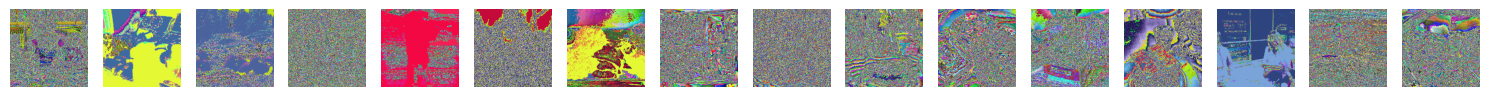

In [154]:
# Set up the plot
plt.figure(figsize=(15, 3))

# Loop through and display each processed image
for i, img in enumerate(images):
    # Check if the image is a tensor and convert it to a NumPy array if needed
    if isinstance(img, torch.Tensor):
        img = img.permute(1, 2, 0).numpy()  # Convert (C, H, W) to (H, W, C)
        img = (img * 255).astype('uint8')  # Convert to [0, 255] range for display

    # Add subplot
    plt.subplot(1, len(images), i + 1)
    plt.imshow(img)
    plt.axis('off')  # Hide the axis

# Show the plot with all processed images
plt.tight_layout()
plt.show()

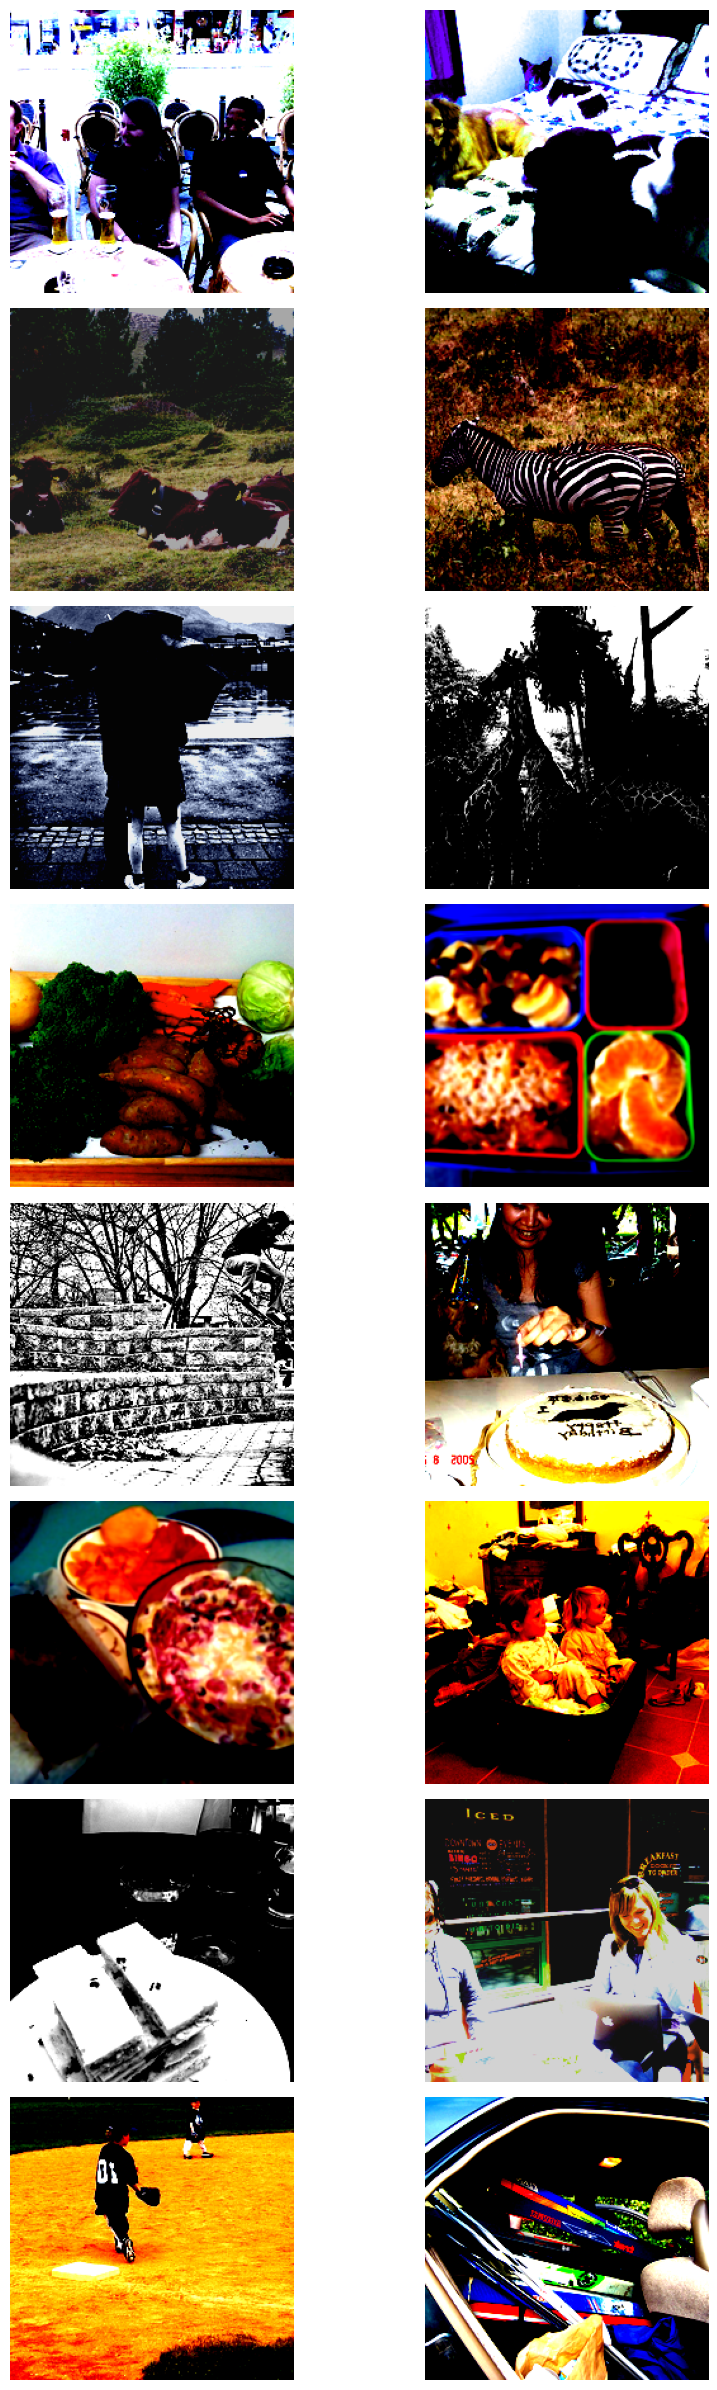

In [155]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Function to denormalize an image
def denormalize(image, mean, std):
    mean = torch.tensor(mean).reshape(1, 1, 3)  # Reshape to match (H, W, C)
    std = torch.tensor(std).reshape(1, 1, 3)
    denormalized_image = image * std + mean
    return denormalized_image
# Calculate the number of rows needed to display images in a 2-column layout
num_images = len(images)
num_cols = 2
num_rows = (num_images + num_cols - 1) // num_cols  # Ceiling division to get the required number of rows

# Set up the plot
plt.figure(figsize=(10, num_rows * 3))  # Adjust the figure size as needed

# Loop through and display each processed image in a grid with denormalization
for i, img in enumerate(images):
    # Denormalize the image
    img = img.permute(1, 2, 0)  # Convert (C, H, W) to (H, W, C)
    img = denormalize(img, mean, std)  # Apply denormalization
    img = torch.clip(img, 0, 1).numpy()  # Clip to valid range [0, 1] and convert to numpy for display

    # Add subplot in a 2-column grid
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img)
    plt.axis('off')  # Hide the axis

# Show the plot with all processed images
plt.tight_layout()
plt.show()